- Hip angle	~90°–120°	Measures how "inverted" the V is
- Shoulder angle	~160°–180°	Arms aligned with back
- Knee angle	~170°–180°	Legs should be straight

# Choosing a set of 20 images that represent the perfect Downward Dog pose
# These images serve as reference examples to calculate the average (mean) joint angles
# and their variability (variance or standard deviation).
# This statistical profile helps define acceptable angle ranges for assessing new poses.

In [27]:
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import pandas as pd
import os
import math
from mediapipe.python.solutions.pose import PoseLandmark
import random


In [28]:
folder_path = "C:/Users/hadhr/Documents/yoga-project/data/DATASET/Perfect_pose"
pose = "downdog"

#rania_path = "C:/Users/hadhr/Documents/yoga-project/notebooks/photo_pris.jpg"

In [ ]:


def calculate_angle(a, b, c):
    """
    Calculates angle (in degrees) between three points:
    a, b, c are (x, y) tuples. b is the vertex.
    """
    a = [a[0], a[1]]
    b = [b[0], b[1]]
    c = [c[0], c[1]]

    # Calculate vectors
    ab = [a[0] - b[0], a[1] - b[1]]
    cb = [c[0] - b[0], c[1] - b[1]]

    # Dot product and magnitude
    dot_product = ab[0]*cb[0] + ab[1]*cb[1]
    mag_ab = math.hypot(ab[0], ab[1])
    mag_cb = math.hypot(cb[0], cb[1])

    # Angle in radians -> degrees
    angle = math.acos(dot_product / (mag_ab * mag_cb + 1e-6))
    return math.degrees(angle)


In [30]:
#
def load_image(image_path):
    image = cv2.imread(image_path)
    #image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
    return image


def detect_landmarks(image_rgb):
    mp_pose = mp.solutions.pose
    with mp_pose.Pose(
        static_image_mode=True,
        model_complexity=1,
        smooth_landmarks=False,
        min_detection_confidence=0.5
    ) as pose:
        results = pose.process(image_rgb)
    return results

def extract_needed_landmarks(results, landmark_names):
    if not results.pose_landmarks:
        return {}
    lm = results.pose_landmarks.landmark
    needed = {}
    for name in landmark_names:
        try:
            landmark_enum = getattr(PoseLandmark, name)
            needed[name] = lm[landmark_enum]
        except AttributeError:
            print(f"Warning: '{name}' is not a valid PoseLandmark")
    return needed

def show_image(image_with_lms):
    plt.imshow(cv2.cvtColor(image_with_lms, cv2.COLOR_BGR2RGB))  
    plt.axis('off')
    plt.title("Needed Landmarks Only")
    plt.show()


def calculate_pose_angles(landmarks_dict, angle_defs):
    get_coords = lambda lm: (lm.x, lm.y)
    results = {}

    for angle_name, p1, vertex, p2 in angle_defs:
        if all(k in landmarks_dict for k in [p1, vertex, p2]):
            a = get_coords(landmarks_dict[p1])
            b = get_coords(landmarks_dict[vertex])
            c = get_coords(landmarks_dict[p2])
            angle = calculate_angle(a, b, c)
            results[angle_name] = angle
        else:
            results[angle_name] = None  # Or raise an error/log warning
    return results

def compute_pose_angles_from_image(image_path,angle_definitions,landmark_list): #general function
    try:
        image = load_image(image_path)
    except Exception as e:
        print(f"Error loading {image_path}: {e}")
    results = detect_landmarks(image)
    if results.pose_landmarks:
        needed_lms = extract_needed_landmarks(results, landmark_list)
    pose_angles = calculate_pose_angles(needed_lms, angle_definitions)
    return pose_angles

In [31]:
train_path = "C:/Users/hadhr/Documents/yoga-project/data/DATASET/TRAIN"
image_path = train_path + '/downdog/00000129.jpg'
landmark_list = [
    'LEFT_SHOULDER', 'LEFT_HIP', 'LEFT_ANKLE',
    'LEFT_KNEE', 'LEFT_ELBOW', 'LEFT_WRIST'
]

# Define which angles to calculate
angle_definitions_downdog = [
    ("Shoulder-Hip-Ankle", "LEFT_SHOULDER", "LEFT_HIP", "LEFT_ANKLE"),
    ("Hip-Knee-Ankle", "LEFT_HIP", "LEFT_KNEE", "LEFT_ANKLE"),
    ("Wrist-Elbow-Shoulder", "LEFT_WRIST", "LEFT_ELBOW", "LEFT_SHOULDER")
]


def compute_pose_angles_from_image(image_path, angle_definitions, landmark_list):
    image = load_image(image_path)
    results = detect_landmarks(image)
    if results.pose_landmarks:
        needed_lms = extract_needed_landmarks(results, landmark_list)
        pose_angles = calculate_pose_angles(needed_lms, angle_definitions)
        return pose_angles, needed_lms
    else:
        # Return empty dicts if no pose detected
        return {}, {}


pose_angles, needed_lms = compute_pose_angles_from_image(image_path,angle_definitions_downdog,landmark_list)
print("angles",pose_angles)


angles {'Shoulder-Hip-Ankle': 54.652084898270196, 'Hip-Knee-Ankle': 177.64467080528163, 'Wrist-Elbow-Shoulder': 166.12389103455772}


In [37]:

def process_pose_images_in_folder(folder_path, angle_definitions, landmark_list):
    all_data = []

    # Loop through all files in the folder
    for filename in os.listdir(folder_path):
        if filename.lower().endswith(('.jpg', '.jpeg', '.png')):  # only images
            image_path = os.path.join(folder_path, filename)

            try:
                # Compute angles for the image
                angles, needed_lms = compute_pose_angles_from_image(image_path, angle_definitions, landmark_list)
                
                # Add filename info
                angles['image_name'] = filename
                all_data.append(angles)
            except Exception as e:
                print(f"Error processing {filename}: {e}")

    # Create a DataFrame
    df = pd.DataFrame(all_data)
    return df

folder = "C:/Users/hadhr/Documents/yoga-project/data/DATASET/Perfect_pose/downdog"
df_angles = process_pose_images_in_folder(folder, angle_definitions_downdog, landmark_list)

# Save to CSV if needed
#df_angles.to_csv("pose_angles_downdog.csv", index=False)

# View the result
#print(df_angles.head())


In [41]:
# Moyenne et écart-type
mean_angles = df_angles[["Shoulder-Hip-Ankle", "Hip-Knee-Ankle", "Wrist-Elbow-Shoulder"]].mean()
std_angles = df_angles[["Shoulder-Hip-Ankle", "Hip-Knee-Ankle", "Wrist-Elbow-Shoulder"]].std()

print("Moyenne :\n", mean_angles)
print("\nÉcart-type :\n", std_angles)

pose = "downdog"
rows = [
    {"pose": pose,"angle_name": angle,"angle_mean": mean,"angle_std": std}
    for (angle, mean), (_, std) in zip(mean_angles.items(), std_angles.items())
]
# Convertir en DataFrame
summary_df = pd.DataFrame(rows)

# Sauvegarder dans un CSV
summary_df.to_csv("angles_stats_downdog.csv", index=False)

print("✅ Fichier angles_stats_downdog.csv sauvegardé.")

Moyenne :
 Shoulder-Hip-Ankle       54.514647
Hip-Knee-Ankle          176.330868
Wrist-Elbow-Shoulder    167.641760
dtype: float64

Écart-type :
 Shoulder-Hip-Ankle      12.754542
Hip-Knee-Ankle           2.628547
Wrist-Elbow-Shoulder     6.569395
dtype: float64
✅ Fichier angles_stats_downdog.csv sauvegardé.


#--------------------------------------------------------------------------------------------------------------------------------------
#--------------------------------------------------------------------------------------------------------------------------------------

In [18]:
# Moyenne et écart-type
mean_angles = df_angles[["Shoulder-Hip-Ankle", "Hip-Knee-Ankle", "Wrist-Elbow-Shoulder"]].mean()
std_angles = df_angles[["Shoulder-Hip-Ankle", "Hip-Knee-Ankle", "Wrist-Elbow-Shoulder"]].std()

print("Moyenne :\n", mean_angles)
print("\nÉcart-type :\n", std_angles)


Moyenne :
 Shoulder-Hip-Ankle       65.739748
Hip-Knee-Ankle          169.569323
Wrist-Elbow-Shoulder    164.880092
dtype: float64

Écart-type :
 Shoulder-Hip-Ankle      28.374762
Hip-Knee-Ankle          21.955275
Wrist-Elbow-Shoulder    14.235488
dtype: float64


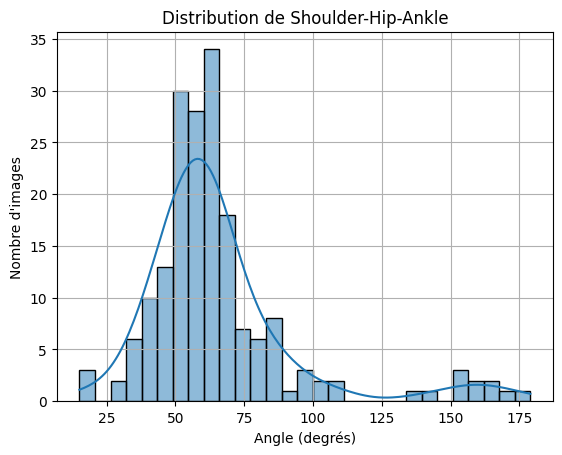

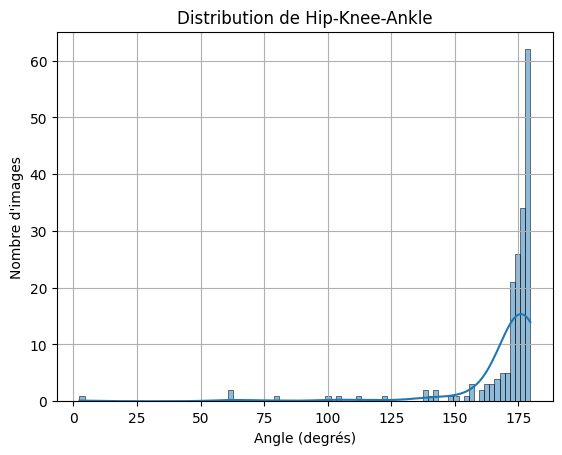

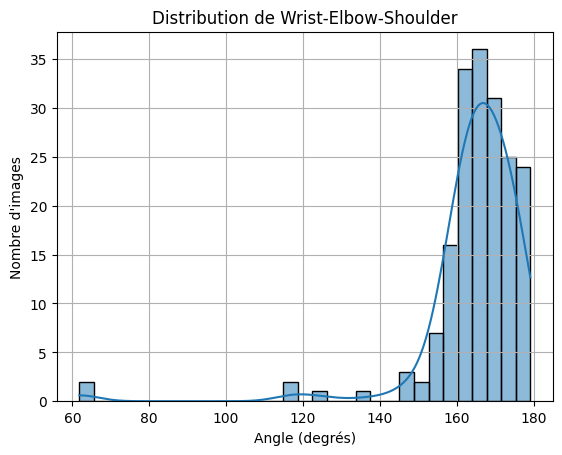

In [ ]:
import seaborn as sns

for col in df_angles.columns[:-1]:  # sauf la dernière si c'est un nom de fichier
    sns.histplot(df_angles[col], kde=True)
    plt.title(f"Distribution de {col}")
    plt.xlabel("Angle (degrés)")
    plt.ylabel("Nombre d'images")
    plt.grid(True)
    plt.show()


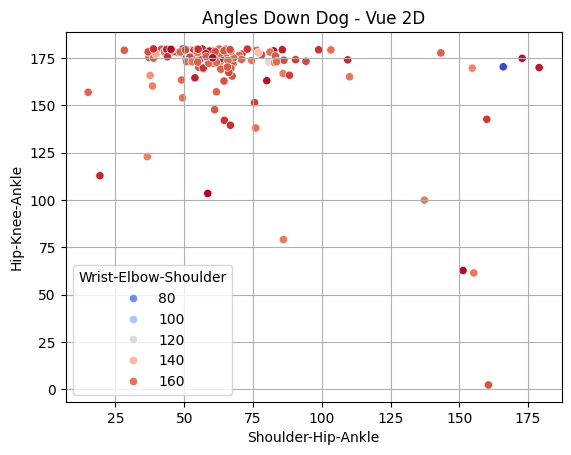

In [29]:
sns.scatterplot(
    data=df_angles,
    x="Shoulder-Hip-Ankle",
    y="Hip-Knee-Ankle",
    hue="Wrist-Elbow-Shoulder",  # couleur selon 3e angle
    palette="coolwarm"
)
plt.title("Angles Down Dog - Vue 2D")
plt.grid(True)
plt.show()


In [10]:
# Moyenne des colonnes d'angles
mean_values = df_angles.drop(columns=["image_name"]).mean()

print("Moyennes des angles :")
print(mean_values)

Moyennes des angles :
Shoulder-Hip-Ankle       65.739748
Hip-Knee-Ankle          169.569323
Wrist-Elbow-Shoulder    164.880092
dtype: float64


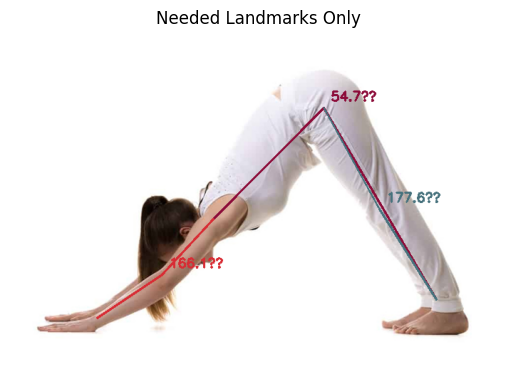

In [ ]:
#drawin angles in the image

initial_image = load_image(image_path)


def generate_color_map(angle_defs, seed=42):
    random.seed(seed)
    return {
        name: tuple(random.randint(0, 255) for _ in range(3))
        for name, _, _, _ in angle_defs
    }

def draw_angle_on_image(image, landmarks_dict, angle_defs, angles, color_map):
    h, w, _ = image.shape
    get_px = lambda lm: (int(lm.x * w), int(lm.y * h))

    for name, p1, vertex, p2 in angle_defs:
        if None in (angles.get(name), landmarks_dict.get(p1), landmarks_dict.get(vertex), landmarks_dict.get(p2)):
            continue

        color = color_map.get(name, (0, 255, 255))
        a = get_px(landmarks_dict[p1])
        b = get_px(landmarks_dict[vertex])
        c = get_px(landmarks_dict[p2])

        # Draw lines representing the angle arms
        cv2.line(image, a, b, color, 2)
        cv2.line(image, c, b, color, 2)

        # Put angle text near vertex
        angle_text = f"{angles[name]:.1f}°"
        cv2.putText(image, angle_text, (b[0]+10, b[1]-10), cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)


color_map = generate_color_map(angle_definitions_downdog)
draw_angle_on_image(initial_image, needed_lms, angle_definitions_downdog, pose_angles, color_map)
show_image(initial_image) 


In [ ]:
# capture photo and exit
import cv2

def take_photo_and_exit():
    cap = cv2.VideoCapture(0)

    if not cap.isOpened():
        print("Error: Cannot open camera")
        return

    ret, frame = cap.read()
    if ret:
        filename = "captured_photo.jpg"
        cv2.imwrite(filename, frame)
        print(f"Photo saved as {filename}")
    else:
        print("Failed to capture photo.")

    cap.release()
    cv2.destroyAllWindows()

take_photo_and_exit()


Photo saved as captured_photo.jpg


In [ ]:
#open camera and use mediapipe live
import cv2
import mediapipe as mp

# Initialize MediaPipe pose
mp_pose = mp.solutions.pose
mp_drawing = mp.solutions.drawing_utils

pose = mp_pose.Pose(min_detection_confidence=0.5, min_tracking_confidence=0.5)

# Start webcam
cap = cv2.VideoCapture(0)  # 0 = default webcam

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    # Convert the image to RGB
    image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

    # Process the image and detect pose
    results = pose.process(image_rgb)

    # Draw the pose annotation on the image
    if results.pose_landmarks:
        mp_drawing.draw_landmarks(
            frame,
            results.pose_landmarks,
            mp_pose.POSE_CONNECTIONS,
            mp_drawing.DrawingSpec(color=(0,255,0), thickness=2, circle_radius=2),
            mp_drawing.DrawingSpec(color=(0,0,255), thickness=2)
        )

    # Show the output
    cv2.imshow('Pose Detection', frame)

    # Break on 'q' key
    if cv2.waitKey(1) & 0xFF == ord('q'):
        break

# Release resources
cap.release()
cv2.destroyAllWindows()


KeyboardInterrupt: 

: 

In [1]:
import cv2
import tkinter as tk
from PIL import Image, ImageTk

class CameraApp:
    def __init__(self, window):
        self.window = window
        self.window.title("Camera App - Prendre une photo")

        # Bouton pour prendre la photo
        self.btn_take_photo = tk.Button(window, text="Prendre la photo", command=self.take_photo)
        self.btn_take_photo.pack()

        # Label pour afficher la vidéo
        self.label = tk.Label(window)
        self.label.pack()

        # Ouvre la caméra
        self.cap = cv2.VideoCapture(0)

        # Démarre la vidéo
        self.update_frame()

    def update_frame(self):
        ret, frame = self.cap.read()
        if ret:
            # Convertir l'image de BGR(OpenCV) à RGB
            cv2image = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
            img = Image.fromarray(cv2image)
            imgtk = ImageTk.PhotoImage(image=img)
            self.label.imgtk = imgtk
            self.label.configure(image=imgtk)
        self.window.after(30, self.update_frame)  # rafraîchir toutes les 30 ms

    def take_photo(self):
        ret, frame = self.cap.read()
        if ret:
            cv2.imwrite("photo_pris.jpg", frame)
            print("Photo prise et sauvegardée sous 'photo_pris.jpg'")

    def __del__(self):
        if self.cap.isOpened():
            self.cap.release()

if __name__ == "__main__":
    root = tk.Tk()
    app = CameraApp(root)
    root.mainloop()


Photo prise et sauvegardée sous 'photo_pris.jpg'


In [ ]:
def check_pose_angles(test_angles, references, tolerance_factor=1.5):
    feedback = {}
    for angle_name, values in references.items():
        mean = values["mean"]
        std = values["std"]
        lower_bound = mean - tolerance_factor * std
        upper_bound = mean + tolerance_factor * std
        
        angle_val = test_angles.get(angle_name)
        if angle_val is None:
            feedback[angle_name] = "Angle not detected"
        elif lower_bound <= angle_val <= upper_bound:
            feedback[angle_name] = "Good"
        else:
            feedback[angle_name] = f"Adjust angle ({angle_val:.1f}° out of range)"
    return feedback